# Introduction

This notebook showcases three of the latest pyspedas features: ionospheric footpath mapping, map plotting, and a new set of ground-based magnetic field measurement stations. 

## Import packages

In [1]:
import pyspedas
from pyspedas import subtract_median
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
from pyspedas.projects.themis.spacecraft.fields.fit import fit
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, add_markers, tvar_to_foottracks, add_tracks
from pyspedas.tplot_tools.MPLPlotter.tplot import tplot
from pyspedas.tplot_tools.get_data import get_data
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

01-Jul-26 17:27:03: c:\Users\DC\Documents\Projects\pyspedas_examples\pyspedas_examples_3_10_dev\lib\site-packages\spacepy\time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()



# The USGS variometers
The United States Geological Survey (USGS) has been installing variometers alongside seismograph instruments as part of the Global Seismograph Network (GSN). These variometers utilize fluxgate magnetometers and are similar in principle to the standard observatory magnetometers; however, the magnetic field measurements can contain substantial offsets, which complicate efforts to use the field data in applications where accurate field magnitude values are essential. 

These variometers are useful because they greatly expand the spatial coverage of ground-based magnetic field observations. Additionally, when only the field variations are of concern--when the mean or median values are subtracted from the field measurements--the variometer data is comparable to the observatory magnetometer data when used under the same treatment. Finally, when available, the THEMIS archive includes two different time resolutions: 1 second and 100 millisecond. The 100 millisecond data has 10 times the sampling rate (10 Hz vs 1 Hz) of the standard USGS observatory magnetometers, and can capture small scale variations which wouldn't be observed otherwise. In conclusion, the variometers represent a valuable addition to the THEMIS GMAG data archive. 

Let's first look at the spatial coverage of these variometer stations by loading their locations onto a map. The new tplot_map method can be used to create plots involving maps of Earth and tplot variables. It works by creating Tplot_Map objects, which inherit attributes and functions from the Basemap object from the basemap module. The tplot_map() method initializes a Tplot_Map object, and can receive initialization options that the parent Basemap object uses (like setting the projection being used, as well as where the map is centered). 

Tplot_Map has helper functions which accept basemap function keyword arguments. For example, Tplot_Map.add_map_boundary() accepts the same keyword arguments as Basemap.drawmapboundary(); however, using the Tplot_Map functions is the only way to update the internal parameter set if duplicate maps are to be produced. 

This internal "_params" attribute can be called directly, and passed a dictionary of keyword options. This redefines the parameter settings completely to what is passed (like in this example,"tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}" removes the saved map boundary options and replaces it with the dictionary {"fill_color":"lightskyblue"}). 

Calling the Tplot_Map class functions (or using update() on the parameter dictionary) only adds/changes the keywords provided, leaving the rest of the options in-place. Examples of this can be seen below in "tmap._params.basemap.update({"llcrnrlon":0,"llcrnrlat":-85,"urcrnrlon":360,"urcrnrlat":85,"projection":'mill'})" and "tmap.add_fillcontinents(color="palegreen",lake_color="lightskyblue")"

Default basemap settings
{'projection': 'ortho', 'lat_0': 0, 'lon_0': 0}
Updated basemap settings:
{'projection': 'mill', 'lat_0': 0, 'lon_0': 0, 'llcrnrlon': 0, 'llcrnrlat': -85, 'urcrnrlon': 360, 'urcrnrlat': 85}


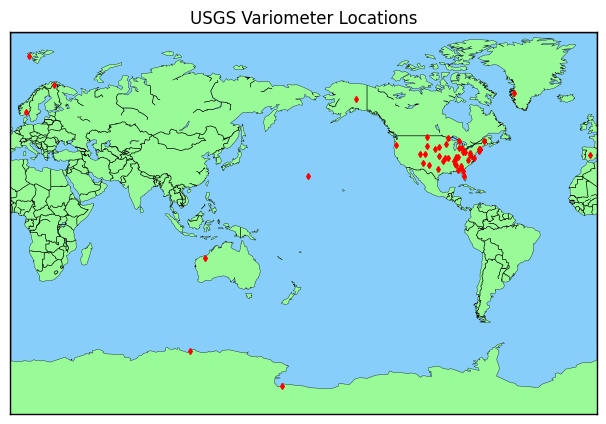

In [2]:
fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

tmap = tplot_map()
print("Default basemap settings")
print(tmap._params.basemap)
tmap._params.basemap.update({"llcrnrlon":0,"llcrnrlat":-85,"urcrnrlon":360,"urcrnrlat":85,"projection":'mill'})
print("Updated basemap settings:")
print(tmap._params.basemap)
tmap.build_map()
# Calling this line accomplishes the same results as the above block of code:
#tmap = tplot_map(llcrnrlon=0,llcrnrlat=-85,urcrnrlon=360,urcrnrlat=85,projection='mill')

tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}
tmap.add_map_boundary()
#tmap._params.fillcontinents = {"color":"palegreen","lake_color":"lightskyblue"}
tmap.add_fillcontinents(color="palegreen",lake_color="lightskyblue")
tmap.add_coastlines(linewidth=0.25)

# Tplot_Map doesn't currently have an add_countries() function yet, but the method can be called in the parent basemap class: 
tmap.drawcountries()

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    # select only the variometer stations:
    if station_dict['variom'] == 'Y':
        # the add_markers function of tplot_map.py calls the add_marker() function of the Tplot_Map object:
        tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3)

# day night terminator can also be added (defaults to current date and time):
#tmap.add_nightshade()
plt.title("USGS Variometer Locations")
plt.show()

By plotting only the USGS variometer network on a map, we can see that while they are concentrated in the lower 48 United States, USGS variometers have locations spanning a large part of the globe--a trait we will leverage when examining spacecraft footpaths. The map below shows the stations in the lower 48 United States without the overlap. A future update to tplot_map will include "views" of specific continents, points of interest, etc.

Default basemap settings
{'projection': 'ortho', 'lat_0': 0, 'lon_0': 0}
Updated basemap settings:
{'projection': 'mill', 'lat_0': 0, 'lon_0': 0, 'llcrnrlon': 225, 'llcrnrlat': 25, 'urcrnrlon': 300, 'urcrnrlat': 50}


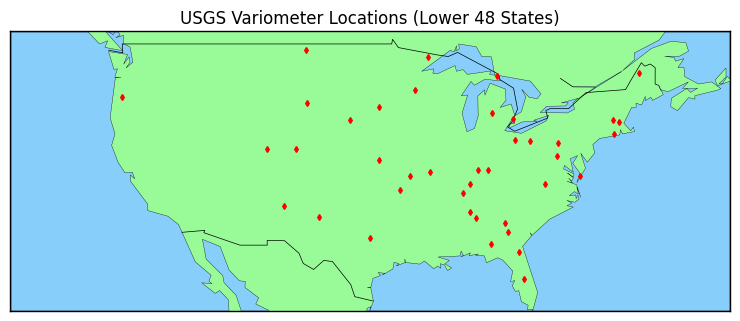

In [3]:
fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

tmap = tplot_map()
print("Default basemap settings")
print(tmap._params.basemap)
tmap._params.basemap.update({"llcrnrlon":225,"llcrnrlat":25,"urcrnrlon":300,"urcrnrlat":50,"projection":'mill'})
print("Updated basemap settings:")
print(tmap._params.basemap)
tmap.build_map()
# Calling this line accomplishes the same results as the above block of code:
#tmap = tplot_map(llcrnrlon=0,llcrnrlat=-85,urcrnrlon=360,urcrnrlat=85,projection='mill')

#tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}
tmap.add_map_boundary(fill_color="lightskyblue")
#tmap._params.fillcontinents = {"color":"palegreen","lake_color":"lightskyblue"}
tmap.add_fillcontinents(color="palegreen",lake_color="lightskyblue")
tmap.add_coastlines(linewidth=0.25)

# Tplot_Map doesn't currently have an add_countries() function yet, but the method can be called in the parent basemap class: 
tmap.drawcountries()

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    # select only the variometer stations:
    if station_dict['variom'] == 'Y':
        # the add_markers function of tplot_map.py calls the add_marker() function of the Tplot_Map object:
        tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3)

# day night terminator can also be added (defaults to current date and time):
#tmap.add_nightshade()
plt.title("USGS Variometer Locations (Lower 48 States)")
plt.show()

More information about station names and locations, as well as data availability and links to access can be found here:
https://themis.ssl.berkeley.edu/gmag/gmag_list.php?selyear=3000&selmonth=13&selsort=ccode&smap=on&sinfo=on&seltxt=0&variom=on

# Conjunction Event with Probes and Variometers

Now let's use the new variometer stations to compare magnetic field data with THEMIS probes! The THEMIS A and THEMIS D probes orbit Earth and measure the local magnetic field using fluxgate magnetometers (the FGM instrument). The Level 2 processed THEMIS data includes on-board spin fits of the FGM measurements in the form of the FIT data variable, which we will be using here. 

We first must decide which timespan of data we're interested in. For this demonstration, we'll use the onset of the January 2026 geomagnetic storm, occuring on January 19, 2026. We're only interested in the day of the 19th, so the start and end dates are the same:

In [4]:
date_str = '2026-01-19'
time_range = [date_str,date_str]

## Select Variometers

Now we must determine which variometer stations to use--to do this, we'll map the footpaths of the THEMIS A and THEMIS D positions for this date down to the surface, and find out which stations are closest (should be a good enough guess to see if they're magnetically connected). To do this, we must create tplot variables related to THEMIS A and THEMIS D positional data using the time range:

In [5]:
state(trange=time_range, probe='a')
state(trange=time_range, probe='d')

01-Jul-26 17:27:15: File is current: themis_data/tha/l1/state/2026/tha_l1_state_20260119.cdf
01-Jul-26 17:27:15: File is current: themis_data/thd/l1/state/2026/thd_l1_state_20260119.cdf


['thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse']

Next, we trace the positional measurements down to the ionosphere using the magnetic field data and map those footpaths to the surface by converting the coordinates into geodetic latitude and longitude. The geodetic latitude is used in favor of geocentric latitude (from conversion to polar coordinates) to account for Earth's oblateness, and to return values similar to what we'd see on a map or GPS, where the local zenith direction is perpendicular to Earth's surface. 

All of this is handled under the hood from the tplot_maps module! We can specify other tplot variables and coordinate systems, but it expects GSM by default. Because tvar_to_foottracks currently only returns lists (as you can trace lists of tplot variable names/strings), we're only looking for the first element of the output lists for individual tplot variable traces/footpaths.

In [6]:
trace_a = (tvar_to_foottracks(tvar_to_trace = 'tha_pos_gsm', model_str = "t89", endpoint = "ionosphere-north"))[0]
trace_d = (tvar_to_foottracks(tvar_to_trace = 'thd_pos_gsm', model_str = "t89", endpoint = "ionosphere-north"))[0]

01-Jul-26 17:27:15: The km parameter is deprecated. Please use units_in, foot_out_units, and trace_out_units instead.
01-Jul-26 17:27:15: Setting units_in, foot_out_units, and trace_out_units to 'km'.
01-Jul-26 17:27:15: Setting units for input_var_re
01-Jul-26 17:27:15: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3


Load IGRF coefficients ...


01-Jul-26 17:27:19: Computed 100/1440 traces so far, current trace time 2026-01-19 01:40:00.000000
01-Jul-26 17:27:21: Computed 200/1440 traces so far, current trace time 2026-01-19 03:20:00.000000
01-Jul-26 17:27:24: Computed 300/1440 traces so far, current trace time 2026-01-19 05:00:00.000000
01-Jul-26 17:27:27: Computed 400/1440 traces so far, current trace time 2026-01-19 06:40:00.000000
01-Jul-26 17:27:32: Computed 500/1440 traces so far, current trace time 2026-01-19 08:20:00.000000
01-Jul-26 17:27:38: Computed 600/1440 traces so far, current trace time 2026-01-19 10:00:00.000000
01-Jul-26 17:27:47: Computed 700/1440 traces so far, current trace time 2026-01-19 11:40:00.000000
01-Jul-26 17:27:57: Computed 800/1440 traces so far, current trace time 2026-01-19 13:20:00.000000
01-Jul-26 17:28:07: Computed 900/1440 traces so far, current trace time 2026-01-19 15:00:00.000000
01-Jul-26 17:28:18: Computed 1000/1440 traces so far, current trace time 2026-01-19 16:40:00.000000
01-Jul-26

The variometer positions are stored in the THEMIS GMAG dictionary, which can be accessed by first initializing the Themis_gmag class:

In [7]:
themis_gmag_dict = gmag.Themis_gmag()

Now we can comput the angular separation (angle between geocentric radial vectors pointing to the geodetic latitude and longitude on Earth's surface), which should be proportional to surface distance, but only the angular separation should be necessesary in determining proximity:

In [8]:
def vpolar_to_vcartesian(theta,phi):
    return (np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta))

def geodetic2geocentric(lat_deg,f=(1/298.26)):
    return np.rad2deg(np.arctan((1/(1-f)**2) * np.tan(np.deg2rad(lat_deg))))

def ang_sep(station_dict:dict,trace_data):
    """
    Determine the angular separation between a station and a probe trace (both the station position and probe trace are given in geodetic degrees)
    """
    s_theta = np.deg2rad(90.0-geodetic2geocentric(lat_deg=float(station_dict['lat'])))
    s_phi = np.deg2rad(float(station_dict['lng']))
    s_x, s_y, s_z = vpolar_to_vcartesian(s_theta,s_phi)
    
    t_theta = np.deg2rad(90.0-geodetic2geocentric(lat_deg=trace_data[:,1]))
    t_phi = np.deg2rad(trace_data[:,2])
    t_x, t_y, t_z = vpolar_to_vcartesian(t_theta,t_phi)
    
    ang_sep_arr = np.rad2deg( np.arccos( (s_x*t_x)+(s_y*t_y)+(s_z*t_z) ) )
    return ang_sep_arr

variom_dist_list = []
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        ang_sep_a = ang_sep(station_dict=station_dict,trace_data=trace_a)
        ang_sep_d = ang_sep(station_dict=station_dict,trace_data=trace_d)
        dist_tuple = (station_dict['ccode'],np.min(ang_sep_a),np.min(ang_sep_d))
        variom_dist_list.append(dist_tuple)

num_listed = 5

print("Top " + str(num_listed) + " closest stations to THEMIS A:")
variom_dist_list.sort(key=lambda distance: distance[1])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[1]) 
#print(variom_dist_list)

print("Top " + str(num_listed) + " closest stations to THEMIS D:")
variom_dist_list.sort(key=lambda distance: distance[2])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[2])

Top 5 closest stations to THEMIS A:
Station: KEVO; angular separation: 0.07 degrees
Station: COR; angular separation: 0.42 degrees
Station: COLA; angular separation: 2.24 degrees
Station: MIDW; angular separation: 3.52 degrees
Station: DGMT; angular separation: 4.51 degrees
Top 5 closest stations to THEMIS D:
Station: KEVO; angular separation: 0.41 degrees
Station: COLA; angular separation: 1.39 degrees
Station: KONO; angular separation: 4.56 degrees
Station: COR; angular separation: 4.57 degrees
Station: MIDW; angular separation: 9.19 degrees


As we can see for Jan 19th 2026, KEVO lies closest to the footpaths of THEMIS A and THEMIS D, and COR, COLA, and even Midway Island (MIDW) are the close as well. Since COLA is fairly close to both probes, we'll the field measurements at COLA, too: 

In [9]:
close_stations = ["KEVO","COLA"]

Let's do a sanity check and plot the footpaths and station positions on a globe to see if our rankings make sense:

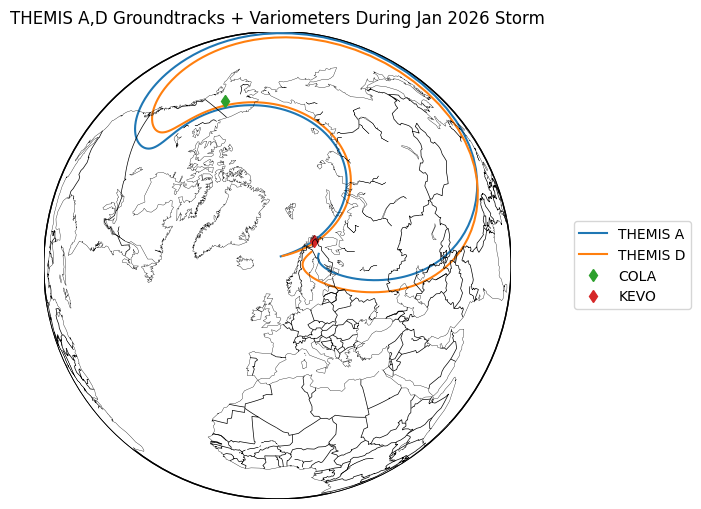

In [10]:
fig=plt.figure(figsize=(8,5.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

mean_lat_a = np.mean((trace_a)[:,1])
mean_lon_a = np.mean((trace_a)[:,2])
mean_lat_d = np.mean((trace_d)[:,1])
mean_lon_d = np.mean((trace_d)[:,2])

mean_lat = np.mean([mean_lat_a,mean_lat_d])
mean_lon = np.mean([mean_lon_a,mean_lon_d])

# Initialize map:
#tmap = tplot_map(lat_0=50,lon_0=80)
tmap = tplot_map(lat_0=mean_lat,lon_0=mean_lon)

tmap._params.add_marker = {"linestyle":"","marker":"d"}

# Add ground tracks:
tmap = add_tracks(tmap=tmap, coords=trace_a, label = 'THEMIS A')
tmap = add_tracks(tmap=tmap, coords=trace_d, label = 'THEMIS D')

station_location_dict = {}

# Add ground station markers
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        if station_dict['ccode'] in close_stations:
            station_location_dict[station_dict['ccode']] = {"lat":float(station_dict['lat']),"lng":float(station_dict['lng'])}
            tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=6)
        
tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
tmap.drawcountries()
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 12:00:00",'%Y-%m-%d %H:%M:%S'))

plt.title("THEMIS A,D Groundtracks + Variometers During Jan 2026 Storm")
ax.legend(loc="center right",bbox_to_anchor=(1, 0, 0.4, 1))
plt.show()

And for Jan 19th 2026, they do! KEVO is almost directly in the connected footpath; granted, the storm onset is later in the day, so we'll need to look at the data to be sure. 

## Compare B Field Measurements

Now we can finally take a look at the magnetic field data! We'll get the FIT spin-fits data variable for THEMIS A and D, and the local ground magnetic field measurements for KEVO and COLA during the date of the storm onset. Because we care about the variations of the field measured at the surface, we'll subtract the median from the KEVO and COLA data:

In [11]:
fit(trange=time_range,probe='a',get_support_data=True)
fit(trange=time_range,probe='d',get_support_data=True)
gmag.gmag(trange=time_range,sites=["kevo","cola"])
subtract_median(['thg_mag_kevo', 'thg_mag_cola'])
# tplot_names()

01-Jul-26 17:30:21: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fit/2026/
01-Jul-26 17:30:22: File is current: themis_data/tha/l2/fit/2026/tha_l2_fit_20260119_v01.cdf
01-Jul-26 17:30:22: Unable to get ydata for variable tha_fgs_sigma
01-Jul-26 17:30:22: Variable tha_fgs_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
01-Jul-26 17:30:22: Variable tha_efs_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
01-Jul-26 17:30:22: Variable tha_fit_bfit_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
01-Jul-26 17:30:22: Variable tha_fit_efit_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
01-Jul-26 17:30:22: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/fit/2026/
01-Jul-2

['thg_mag_kevo-m', 'thg_mag_cola-m']

With out data ready to go, we can calculate the angular separations for just the stations in question and plot the angular separation alongside the magnetic field data to get a feel for how close both probes were at the time of the storm onset. We'll only look at the latter part of the day, so that the storm onset is clearly visible. The rest is a matter of using tplot functions and setting options to make the plots look as pretty as we can:

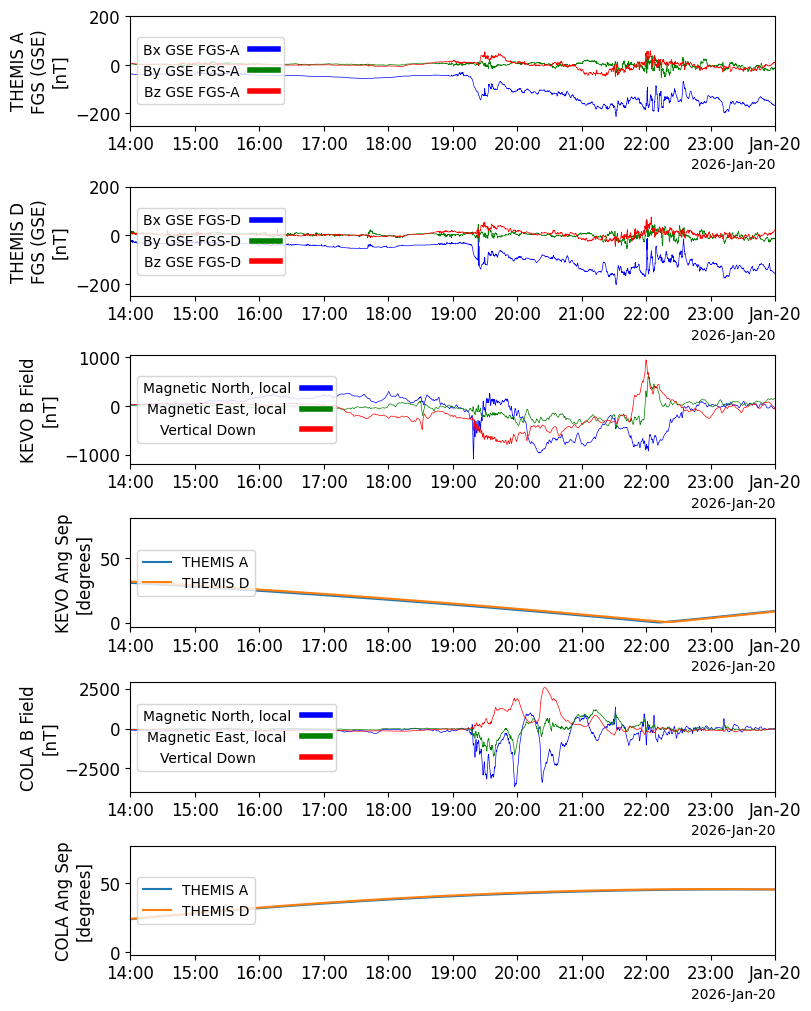

01-Jul-26 17:30:29: C:\Users\DC\AppData\Local\Temp\ipykernel_15388\3395736606.py:37: UserWarning: The figure layout has changed to tight
  fig.tight_layout()



In [12]:
fig, axs = plt.subplots(6,layout="constrained",figsize=(8,10))

ang_sep_kevo_a = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_a)
ang_sep_kevo_d = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_d)
ang_sep_cola_a = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_a)
ang_sep_cola_d = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_d)

for ax in axs:
    ax.set_xlim([dt.datetime(2026, 1, 19, 14, 0, tzinfo=dt.timezone.utc),dt.datetime(2026, 1, 20, 0, 0, tzinfo=dt.timezone.utc)])
axs[0].set_ylim(bottom=-250,top=200)
axs[1].set_ylim(bottom=-250,top=200)

axs[3].set_ylabel(f"KEVO Ang Sep\n[degrees]",fontsize=12)
axs[3].tick_params(axis='both', which='major', labelsize=12)
axs[5].set_ylabel(f"COLA Ang Sep\n[degrees]",fontsize=12)
axs[5].tick_params(axis='both', which='major', labelsize=12)

axs[3].plot(mdates.num2date((get_data("tha_pos_gsm").times)/(3600*24)),ang_sep_kevo_a,label="THEMIS A")
axs[3].plot(mdates.num2date((get_data("thd_pos_gsm").times)/(3600*24)),ang_sep_kevo_d,label="THEMIS D")
axs[5].plot(mdates.num2date((get_data("tha_pos_gsm").times)/(3600*24)),ang_sep_cola_a,label="THEMIS A")
axs[5].plot(mdates.num2date((get_data("thd_pos_gsm").times)/(3600*24)),ang_sep_cola_d,label="THEMIS D")

axs[3].legend(loc="center left")
axs[5].legend(loc="center left")

pyspedas.options("tha_fgs_gse", opt_dict={'ytitle':'THEMIS A\nFGS (GSE)'})
pyspedas.options("thd_fgs_gse", opt_dict={'ytitle':'THEMIS D\nFGS (GSE)'})
pyspedas.options("thg_mag_kevo-m", opt_dict={'ytitle':'KEVO B Field','ysubtitle':'[nT]'})
pyspedas.options("thg_mag_cola-m", opt_dict={'ytitle':'COLA B Field','ysubtitle':'[nT]'})

fig,axs = tplot(
    ['tha_fgs_gse','thd_fgs_gse','thg_mag_kevo-m','thg_mag_cola-m'],
    fig=fig,axis=[axs[0],axs[1],axs[2],axs[4]],
    return_plot_objects=True,
    pseudo_yaxis_options={'legend_location':'center left'},)

fig.tight_layout()

The data for KEVO is very interesting--both COLA and KEVO see the storm onset, but KEVO sees it first AND peaks in the down component right as the footpoints for THEMIS A and D pass by the station. There is some activity in the probe field measurements which suggests the probes were in magnetic conjunction with KEVO around the time of the storm onset.